## Importing the libraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import json

import warnings
warnings.filterwarnings('ignore')

## Importing the dataset

In [2]:
df = pd.read_csv('../../dataSet/marketing_and_sales_clean.csv')

## Splitting the dataset into the Training set and Test set

In [3]:
X = df[['TV', 'Radio', 'Influencer', 'Social Media']].values
y = df['Sales'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

## Training

Le MLP nécessite un StandardScaler pour équilibrer les échelles des featurs. Dans le cas contraire les gradients divergent.<br/>
Le scaler est intégré dans un Pipeline pour éviter tout data leakage et
permettre un déploiement propre en prod.

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=2000, random_state=0))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
}

lm = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lm.fit(X_train, y_train)
best_model = lm.best_estimator_

Ici param_grid contient une liste de possibilité pour chacune des 3 variables à haute importance de notre modèle. <br/>
Ce dictionnaire servira à "GridSearchCV" qui fera des combinaisons en se basant sur les différents paramètres et nous renverra le paramètrage du model le plus efficient. <br/>
En l'occurence :
- 'mlp__activation': 'relu',
- 'mlp__alpha': 0.01,
- 'mlp__hidden_layer_sizes': (32,)

In [5]:
print('Meilleurs paramètres:', lm.best_params_)

Meilleurs paramètres: {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (32,)}


## Prédiction

Text(0, 0.5, 'Predicted Y')

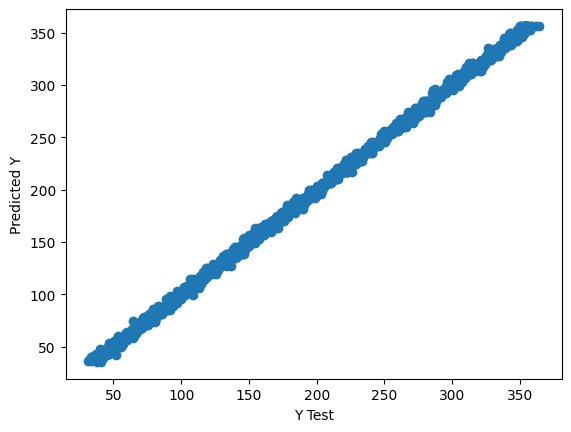

In [6]:
predictions = best_model.predict(X_test)
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Regression Evaluation Metrics

In [ ]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f'MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n')
with open('../saved_models/mlp_regressor/metrics.json', 'w') as f:
    f.write(json.dump({MAE, MSE, RMSE, R2}))

MAE : 2.410321417721798
MSE : 9.164358336087863
RMSE : 3.0272691218469268
R2 : 0.9989576552456974



## Analyse des résidus

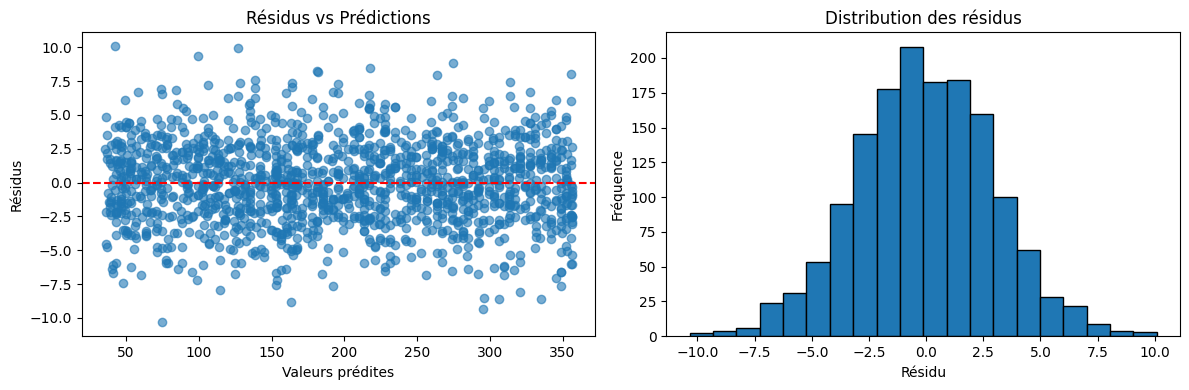

In [8]:
residuals = y_test - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(predictions, residuals, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédictions')

axes[1].hist(residuals, bins=20, edgecolor='black')
axes[1].set_xlabel('Résidu')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

### Résidus vs Prédictions
Les résidus sont dispersés aléatoirement autour de la ligne rouge (y=0), cela signifie que le modèle fait des sur-prédiction & sous-prédiction au même niveau. Pas de déséquillibre.

### Distribution des résidus
On observe une distribution normale autour de 0 avec un écart-type d'environ 3 ce qui concorde avec la métrique RMSE affichée plus tôt.

## Export model

In [ ]:
import pickle
import os

os.makedirs('../saved_models/mlp_regressor', exist_ok=True)

# Sauvegarder le Pipeline complet (scaler + MLP) pour l'inférence en production
with open('../saved_models/mlp_regressor/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)